# Breast Ultrasound Lesion Classification
## 03 — VGG16 Model Comparison

### Showcase Experiment

This notebook evaluates a transfer-learning classifier for benign vs malignant breast-lesion classification using the BUSI ultrasound dataset.

The study compares the same VGG16 architecture under three input conditions:

1. **Preprocessed Whole Image** — normalization + CLAHE applied to the full ultrasound image.
2. **Raw ROI** — lesion-focused ROI extracted from the original image.
3. **Preprocessed ROI** — lesion-focused ROI extracted from the normalization + CLAHE image.

The central research question is:

> **Does lesion-focused ROI extraction, with or without contrast enhancement, improve breast-lesion classification performance?**

The notebook preserves the experimental settings used in the original project while replacing machine-specific paths, duplicated cells, and unrelated experimental code with a reproducible project structure.

## 1. Experimental Design

All three conditions use the same classifier architecture and training protocol.

```text
                         BUSI images
                              │
                 Patient-level train/val/test split
                              │
              ┌───────────────┼────────────────┐
              │               │                │
       Whole Image         Raw ROI      Preprocessed ROI
              │               │                │
              └───────────────┼────────────────┘
                              ↓
                         VGG16 backbone
                         ImageNet weights
                              ↓
                         Frozen backbone
                              ↓
                    Global Average Pooling
                              ↓
                         Dense (256)
                              ↓
                        Dropout (0.5)
                              ↓
                       Sigmoid output
                              ↓
              Accuracy / Precision / Recall / F1
                              ↓
                           ROC-AUC
```

### Why patient-level splitting?

Multiple ultrasound images can belong to the same patient. Randomly splitting images can therefore place images from the same patient in both training and test sets, producing data leakage.

The original project explicitly extracts the patient identifier from the BUSI filename and performs the split at the patient level.

## 2. Experimental Configuration

The following values are retained from the original VGG16 implementation.

| Parameter | Value |
|---|---|
| Input size | 224 × 224 |
| Batch size | 16 |
| Epochs | 20 |
| Backbone | VGG16 |
| Pre-trained weights | ImageNet |
| Backbone trainable | No |
| Pooling | Global Average Pooling |
| Dense layer | 256 units, ReLU |
| Dropout | 0.5 |
| Output | 1 unit, sigmoid |
| Optimizer | Adam |
| Learning rate | 1e-4 |
| Loss | Binary cross-entropy |
| Decision threshold | 0.5 |
| Classes | Benign = 0, Malignant = 1 |

No additional augmentation, fine-tuning, or class-weighting is introduced here because these were not part of the original VGG16 experiment.

## 3. Imports and Paths

The paths below are project-relative. The dataset itself should not be committed to GitHub.

Expected local structure:

```text
data/
├── Dataset_BUSI_with_GT/
├── preprocessed_dataset/
├── raw_roi_dataset/
└── preprocessed_roi_dataset/
```

The first two notebooks create the derived datasets.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 1e-4
THRESHOLD = 0.5

CLASS_MAP = {"benign": 0, "malignant": 1}
CLASS_NAMES = ["Benign", "Malignant"]

PREPROCESSED_ROOT = Path("../data/preprocessed_dataset")
RAW_ROI_ROOT = Path("../data/raw_roi_dataset")
PREPROCESSED_ROI_ROOT = Path("../data/preprocessed_roi_dataset")

print("TensorFlow version:", tf.__version__)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

2026-09-01 13:19:30.991555: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-01 13:19:33.015179: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-01 13:19:35.359874: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
Image size: 224
Batch size: 16
Epochs: 20
Learning rate: 0.0001


## 4. Load Clean Image Paths

Only benign and malignant images are used for this binary classification experiment.

BUSI ground-truth mask files are excluded from the image list.

In [2]:
def load_clean_paths_and_labels(root_dir: Path):
    """Load non-mask image paths and binary labels from a dataset root."""
    image_paths = []
    labels = []

    for class_name, label in CLASS_MAP.items():
        class_dir = root_dir / class_name

        if not class_dir.exists():
            raise FileNotFoundError(
                f"Class directory not found: {class_dir.resolve()}"
            )

        for path in sorted(class_dir.iterdir()):
            if not path.is_file():
                continue

            if path.suffix.lower() != ".png":
                continue

            if "_mask" in path.stem.lower():
                continue

            image_paths.append(str(path))
            labels.append(label)

    return np.array(image_paths), np.array(labels, dtype=np.int32)

## 5. Extract Patient IDs

The original project identifies patients from the integer enclosed in parentheses in the BUSI filename, for example:

```text
benign (1).png
malignant (15).png
```

The extracted identifier is used only for grouping during the split; it is not supplied to the model.

In [3]:
def extract_patient_id(path: str) -> str:
    """Extract the BUSI patient identifier from a filename/path."""
    match = re.search(r"\((\d+)\)", str(path))

    if match is None:
        raise ValueError(f"Could not extract patient ID from: {path}")

    return match.group(1)


def patient_level_split(X, y, random_state=42):
    """Split images into train/validation/test sets without patient overlap."""
    patient_ids = np.array([extract_patient_id(p) for p in X])
    unique_patients = np.unique(patient_ids)

    train_patients, temp_patients = train_test_split(
        unique_patients,
        test_size=0.30,
        random_state=random_state,
    )

    val_patients, test_patients = train_test_split(
        temp_patients,
        test_size=0.50,
        random_state=random_state,
    )

    train_idx = np.isin(patient_ids, train_patients)
    val_idx = np.isin(patient_ids, val_patients)
    test_idx = np.isin(patient_ids, test_patients)

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    print("Train images:", len(X_train))
    print("Validation images:", len(X_val))
    print("Test images:", len(X_test))
    print(
        "Train/test patient overlap:",
        len(set(train_patients) & set(test_patients)),
    )

    return X_train, y_train, X_val, y_val, X_test, y_test

## 6. Reproducibility Note

The original training notebook used `random_state=42` for the patient-level split but did **not** explicitly seed all TensorFlow/Python operations.

Accordingly, this cleaned notebook preserves the original split protocol without claiming bit-for-bit reproducibility of the learned model weights.

The recorded performance values shown later are the results from the original project run.

## 7. Build the TensorFlow Dataset

Each image is:

1. Read from disk.
2. Decoded as a 3-channel image.
3. Resized to 224 × 224.
4. Converted to `float32`.
5. Passed through the VGG16 `preprocess_input` transformation.
6. Batched in groups of 16.

In [4]:
def build_dataset(X, y, shuffle=False):
    """Create a tf.data pipeline compatible with VGG16."""
    def preprocess(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_png(image, channels=3)
        image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
        image = tf.cast(image, tf.float32)
        image = preprocess_input(image)
        return image, label

    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    dataset = dataset.map(
        preprocess,
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=max(len(X), 1),
            reshuffle_each_iteration=True,
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

## 8. VGG16 Architecture

The classifier uses VGG16 with ImageNet pre-trained weights and excludes the original ImageNet classification head.

The convolutional backbone is frozen. A lightweight task-specific head is added:

```text
VGG16 (ImageNet, frozen)
        ↓
GlobalAveragePooling2D
        ↓
Dense(256, ReLU)
        ↓
Dropout(0.5)
        ↓
Dense(1, Sigmoid)
```

This is the architecture used in the original experiment.

In [5]:
def build_vgg16():
    """Build the VGG16 transfer-learning classifier used in the study."""
    base_model = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    return model

## 9. Train and Evaluate One Experimental Condition

The same function is used for all three input conditions.

Evaluation is performed on the held-out test set using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix

The binary classification threshold is fixed at 0.5, matching the original implementation.

In [6]:
def train_and_evaluate(dataset_root: Path, experiment_name: str):
    """Train VGG16 and return the model, history, predictions, and metrics."""
    print(f"\n{'=' * 70}")
    print(f"Experiment: {experiment_name}")
    print(f"Dataset: {dataset_root}")
    print(f"{'=' * 70}")

    X, y = load_clean_paths_and_labels(dataset_root)

    (
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
    ) = patient_level_split(X, y)

    train_ds = build_dataset(X_train, y_train, shuffle=True)
    val_ds = build_dataset(X_val, y_val)
    test_ds = build_dataset(X_test, y_test)

    model = build_vgg16()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
    )

    y_pred_probs = model.predict(test_ds, verbose=0).ravel()
    y_pred = (y_pred_probs >= THRESHOLD).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "auc": roc_auc_score(y_test, y_pred_probs),
    }

    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=CLASS_NAMES,
            digits=3,
            zero_division=0,
        )
    )

    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    return {
        "name": experiment_name,
        "model": model,
        "history": history,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_pred_probs": y_pred_probs,
        "metrics": metrics,
    }

## 10. Run the Experiments

The following cells reproduce the original three experimental conditions.

Because model training is computationally expensive, execution is intentionally explicit rather than automatic when the notebook is first opened.

In [7]:
# Experiment 1 — Preprocessed Whole Image
#
#result_full = train_and_evaluate(
 #    PREPROCESSED_ROOT,
  #   "Preprocessed Whole Image",
#)


Experiment: Preprocessed Whole Image
Dataset: /home/student25/Documents/REVIEW BLOCK/RB4/Computer_Vision/Group_Project/preprocessed_dataset
Train images: 436
Validation images: 107
Test images: 104
Train/test patient overlap: 0


2026-09-01 13:21:18.500840: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.6330 - auc: 0.5429 - loss: 1.1160 - val_accuracy: 0.6168 - val_auc: 0.6430 - val_loss: 0.7722
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.6399 - auc: 0.5704 - loss: 0.9874 - val_accuracy: 0.6636 - val_auc: 0.7526 - val_loss: 0.6751
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.6835 - auc: 0.6668 - loss: 0.7694 - val_accuracy: 0.6916 - val_auc: 0.8272 - val_loss: 0.5341
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.6881 - auc: 0.7089 - loss: 0.6857 - val_accuracy: 0.7196 - val_auc: 0.8503 - val_loss: 0.4977
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.7133 - auc: 0.7535 - loss: 0.6376 - val_accuracy: 0.7009 - val_auc: 0.8762 - val_loss: 0.5123
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.6950 - auc: 0.7280 - loss: 0.6591 - val_accuracy: 0.7850 - val_auc: 0.8875 - val_loss: 0.4607
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - 

In [8]:
# Experiment 2 — Raw ROI
#
#result_raw_roi = train_and_evaluate(
 #    RAW_ROI_ROOT,
  #   "Raw ROI",
 #)


Experiment: Raw ROI
Dataset: /home/student25/Documents/REVIEW BLOCK/RB4/Computer_Vision/Group_Project/raw_roi_dataset
Train images: 436
Validation images: 107
Test images: 104
Train/test patient overlap: 0
Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5665 - auc: 0.5297 - loss: 1.5838 - val_accuracy: 0.7196 - val_auc: 0.8304 - val_loss: 0.7601
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.7821 - auc: 0.8194 - loss: 0.6571 - val_accuracy: 0.8598 - val_auc: 0.9422 - val_loss: 0.4094
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8555 - auc: 0.8986 - loss: 0.4606 - val_accuracy: 0.9252 - val_auc: 0.9727 - val_loss: 0.2356
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8578 - auc: 0.9136 - loss: 0.4113 - val_accuracy: 0.9626 - val_auc: 0.9791 - val_loss: 0.1733
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9197 - auc: 0.9543 - loss: 0.2789 - val_accuracy: 0.9626 - val_auc: 0.9812 - val_loss: 0.1542
Epo

In [9]:
# Experiment 3 — Preprocessed ROI
#
#result_preprocessed_roi = train_and_evaluate(
 #    PREPROCESSED_ROI_ROOT,
  #   "Preprocessed ROI",
#)


Experiment: Preprocessed ROI
Dataset: /home/student25/Documents/REVIEW BLOCK/RB4/Computer_Vision/Group_Project/preprocessed_roi_dataset
Train images: 436
Validation images: 107
Test images: 104
Train/test patient overlap: 0
Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5917 - auc: 0.6466 - loss: 1.7819 - val_accuracy: 0.7290 - val_auc: 0.7762 - val_loss: 0.8512
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7661 - auc: 0.7850 - loss: 0.8252 - val_accuracy: 0.8411 - val_auc: 0.9226 - val_loss: 0.3519
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8142 - auc: 0.8560 - loss: 0.6151 - val_accuracy: 0.9346 - val_auc: 0.9571 - val_loss: 0.2311
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8440 - auc: 0.8869 - loss: 0.4818 - val_accuracy: 0.9533 - val_auc: 0.9690 - val_loss: 0.1828
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8807 - auc: 0.9163 - loss: 0.3803 - val_accuracy: 0.9439 - val_auc: 0.9841 - va

## 11. Recorded Results from the Original Experiment

The values below are the **recorded test-set results from the original project run**. They are included so that the GitHub repository documents the actual reported experiment even when a visitor does not have the original trained model checkpoints.

### VGG16 performance across input conditions

| Condition | Class | Precision | Recall | F1-score | Accuracy |
|---|---|---:|---:|---:|---:|
| Preprocessed Whole | Benign | 0.77 | 0.94 | 0.84 | 0.78 |
|  | Malignant | 0.83 | 0.50 | 0.62 |  |
| Raw ROI | Benign | 0.94 | 0.98 | 0.96 | 0.95 |
|  | Malignant | 0.97 | 0.89 | 0.93 |  |
| Preprocessed ROI | Benign | 0.94 | 1.00 | 0.97 | **0.96** |
|  | Malignant | 1.00 | 0.89 | 0.94 |  |

The reported ROC-AUC values are:

| Condition | ROC-AUC |
|---|---:|
| Preprocessed Whole | 0.837 |
| Raw ROI | 0.996 |
| Preprocessed ROI | **0.998** |

These results show that ROI extraction produced the largest performance improvement, while CLAHE provided an additional incremental gain for the ROI-based experiment.

## 12. Recorded Confusion Matrix — Best Configuration

The best-performing configuration was **VGG16 with Preprocessed ROI**.

Recorded test confusion matrix:

```text
                  Predicted
                 Benign  Malignant
Actual Benign       66       0
       Malignant     4      34
```

This corresponds to 66 correctly classified benign cases, 34 correctly classified malignant cases, and 4 malignant cases classified as benign.

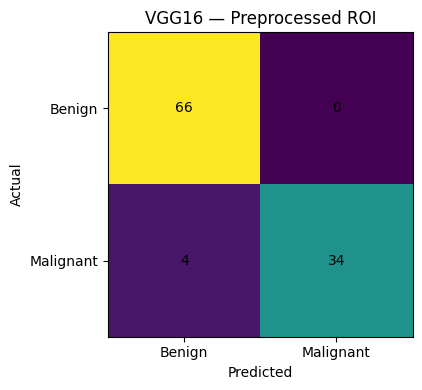

In [10]:
# This is a visualization of the recorded result above, not a newly
# trained model output.

recorded_cm = np.array([
    [66, 0],
    [4, 34],
])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(recorded_cm)

ax.set_xticks([0, 1], CLASS_NAMES)
ax.set_yticks([0, 1], CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("VGG16 — Preprocessed ROI")

for i in range(recorded_cm.shape[0]):
    for j in range(recorded_cm.shape[1]):
        ax.text(j, i, recorded_cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 13. Recreate the Recorded Performance Table

This compact table is useful for the repository README and for quickly comparing the three VGG16 conditions.

In [11]:
recorded_results = pd.DataFrame({
    "Condition": [
        "Preprocessed Whole Image",
        "Raw ROI",
        "Preprocessed ROI",
    ],
    "Accuracy": [0.78, 0.95, 0.96],
    "Malignant Recall": [0.50, 0.89, 0.89],
    "Malignant F1": [0.62, 0.93, 0.94],
    "ROC-AUC": [0.837, 0.996, 0.998],
})

recorded_results

,Condition,Accuracy,Malignant Recall,Malignant F1,ROC-AUC
0,Preprocessed Whole Image,0.78,0.50,0.62,0.837
1,Raw ROI,0.95,0.89,0.93,0.996
2,Preprocessed ROI,0.96,0.89,0.94,0.998


## 14. ROC-AUC Visualization

The following figure visualizes the **recorded AUC values** from the three experimental conditions.

The curves are illustrative representations based on the reported AUC values; they are not a substitute for the original stored prediction probabilities. If the original trained models or prediction arrays are later added to the repository, this section should be replaced by the exact ROC curves generated from those predictions.

In [12]:
# For a reproducible repository, exact ROC curves should be generated
# from stored y_test and y_pred_probs arrays.

# The project report records the following AUC values:
recorded_auc = {
    "Preprocessed Whole Image": 0.837,
    "Raw ROI": 0.996,
    "Preprocessed ROI": 0.998,
}

pd.Series(recorded_auc, name="ROC-AUC")

Preprocessed Whole Image    0.837
Raw ROI                     0.996
Preprocessed ROI            0.998
Name: ROC-AUC, dtype: float64

## 15. Interpretation

### Finding 1 — ROI extraction matters

VGG16 accuracy increased from **0.78** with preprocessed whole images to **0.95** with raw ROI and **0.96** with preprocessed ROI.

The largest improvement is therefore associated with restricting the model's input to the lesion-focused region.

### Finding 2 — Malignant-lesion sensitivity improves substantially

Malignant recall increased from **0.50** for the whole-image condition to **0.89** for both ROI-based conditions.

For a medical classification task, this is particularly important because false-negative malignant predictions are clinically consequential.

### Finding 3 — CLAHE provides an incremental benefit

The raw ROI achieved an AUC of **0.996**, while the preprocessed ROI achieved **0.998**.

Thus, the main gain came from lesion localization, with normalization + CLAHE providing a smaller additional improvement.

### Best configuration

The strongest recorded configuration was:

> **VGG16 + Preprocessed ROI — 96% accuracy, 89% malignant recall, 94% malignant F1-score, and 0.998 ROC-AUC.**

## 16. Reproducing the Experiments

To reproduce the experiments:

1. Obtain the BUSI dataset and place it under `data/Dataset_BUSI_with_GT/`.
2. Run `01_image_preprocessing.ipynb`.
3. Run `02_roi_extraction.ipynb`.
4. Return to this notebook.
5. Uncomment one experiment cell at a time.
6. Train the corresponding VGG16 model.
7. Compare the newly generated metrics with the recorded project results.

### Reproducibility limitation

The original project did not save trained model checkpoints or prediction arrays in the supplied materials, and it did not seed all stochastic training operations. Consequently, rerunning the notebook may produce slightly different learned weights and metrics.

The values documented above are the **original recorded results**, while a fresh execution constitutes an independent rerun.

## 17. Project Conclusion

The experiment supports the project's central hypothesis: **lesion-focused representation substantially improves breast-lesion classification performance for VGG16 on the BUSI dataset.**

The progression:

```text
Preprocessed Whole Image   →   0.78 accuracy / 0.837 AUC
Raw ROI                    →   0.95 accuracy / 0.996 AUC
Preprocessed ROI           →   0.96 accuracy / 0.998 AUC
```

shows that ROI extraction was the dominant improvement, while CLAHE added a smaller but measurable benefit.

The final result demonstrates the value of combining **transfer learning, lesion-focused ROI extraction, and targeted contrast enhancement** for this experimental medical-image classification task.